**MICKEY ZHNAG**

Spring 2026

CS 251/2: Data Analysis and Visualization

Project 3: Linear regression

#### Week 2: Polynomial regression

In [104]:
import numpy as np
import matplotlib.pyplot as plt

import data
import linear_regression

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## CS252 Note

For full credit, please use your Normal Equations least squares solver throughout this notebook.

## Task 3: Polynomial Regression

We have been creating linear regression fits of form $y =c_0 + c_1x_1 + c_2x_2 + \ldots$, where $x_i$ are independent variables (columns of $A$) and $c_i$ are corresponding coefficients in $c$. However, this equation only allows us to fit data with a line/plane. This may not be the best choice for all datasets.

In this task, you will generalize the linear regression model form to include higher-degree (>1) polynomial terms and explore how this may improve fits to complex data. For example, assume we're doing a simple linear regression with independent variable $x_1$ and dependent variable $y$. A linear regression that fits data with a quadratic shape has the form$$y = c_0 + c_1x_1 + c_2x_1^2$$

Complete the following steps to add support for polynomial regression in your `LinearRegression` class.

### 3a. Build the polynomial matrix of the independent variable

The polynomial matrix contains the independent variable raised to a different power in each column. For example, if $A$ originally has a column vector for the independent variable $\vec{x_1}$ ($A = [\vec{x_1}]$) and we wanted to make the above quadratic model, we would append $x_1^2$ ($A = [\vec{x_1}, \vec{x_1^2}]$).

**TODO:**
Implement and test `LinearRegression::make_polynomial_matrix` (*helper method*) that takes care of raising the independent variable samples to different powers.

##### Test `make_polynomial_matrix`

In [105]:
test_A = np.r_[1:10].reshape((9, 1))
test_p = 3

# Test cubic
lin_reg = linear_regression.LinearRegression(data.Data())
print(f'Your polynomial matrix:\n{lin_reg.make_polynomial_matrix(test_A, 3)}')

true_mat = '''
[[  1.   1.   1.]
 [  2.   4.   8.]
 [  3.   9.  27.]
 [  4.  16.  64.]
 [  5.  25. 125.]
 [  6.  36. 216.]
 [  7.  49. 343.]
 [  8.  64. 512.]
 [  9.  81. 729.]]
'''
print('It should look like:\n', true_mat)

Your polynomial matrix:
[[  1   1   1]
 [  2   4   8]
 [  3   9  27]
 [  4  16  64]
 [  5  25 125]
 [  6  36 216]
 [  7  49 343]
 [  8  64 512]
 [  9  81 729]]
It should look like:
 
[[  1.   1.   1.]
 [  2.   4.   8.]
 [  3.   9.  27.]
 [  4.  16.  64.]
 [  5.  25. 125.]
 [  6.  36. 216.]
 [  7.  49. 343.]
 [  8.  64. 512.]
 [  9.  81. 729.]]



### 3b. Add support for polynomial regression

This can be performed in 3 steps:


1. Implement the `LinearRegression::polynomial_regression` method to perform the polynomial regression (*alternate option: you may instead update your `linear_regression` method. If you decide to go this route, add a keyword argument for the polynomial degree with a default value of 1 to preserve compatability with regular linear regression.*).
2. Update `LinearRegression::predict`: Run `make_polynomial_matrix` on the "A" matrix that enters into the computation $y = Ac$ if `self.p > 1`.
3. Add support for plotting polynomials in `LinearRegression::scatter` by generalizing the plotted regression line to a regression polynomial if `self.p > 1`:
    - Getting your polynomial "x" values: Run `make_polynomial_matrix` on your evenly-spaced line sample points. To get the shapes to work out, you may need to add a trailing singleton dimension to your "x" sample points. For example, if you have 1000 "x" sample points, make the shape `(1000, 1)` rather than `(1000,)`.
    - Getting your polynomial "y" values: Use matrix multiplication with your polynomial regression model slopes and/or intercepts.

*There is no explicit test code here — visualizing the fit in the next subtask will help you debug!*

### 3c. Test polynomial regression with linear and cubic models

This subtask will help to make sure your polynomial regression implementation is working.

1. In the cell below, fit the `wave_fit.csv` dataset using polynomial regression where the polynomial degree $p = 1$ and separately with $p = 10$.
2. Use `scatter` to plot the results.
3. Print out the mean squared error.

The plot for the $p=1$ regression should "look right" to you and the $p=10$ fit should show visually distinct "wiggles".

In [106]:
poly_data_filename = 'data/wave_fit.csv'
poly_data = data.Data(poly_data_filename)
print(poly_data)

------------------------------
data/wave_fit.csv (150x2)
Headers:
x	y
------------------------------
Showing first 5/150 rows.
2.0858	-0.4942
4.6724	-5.85
2.4812	-3.3264
0.2579	4.5996
-0.9518	4.9771


MSE (p=1): 4.402518022533747
MSE (p=10): 4.353802650593322


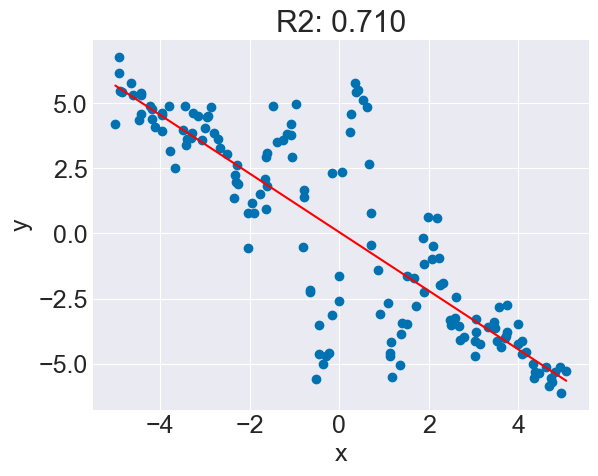

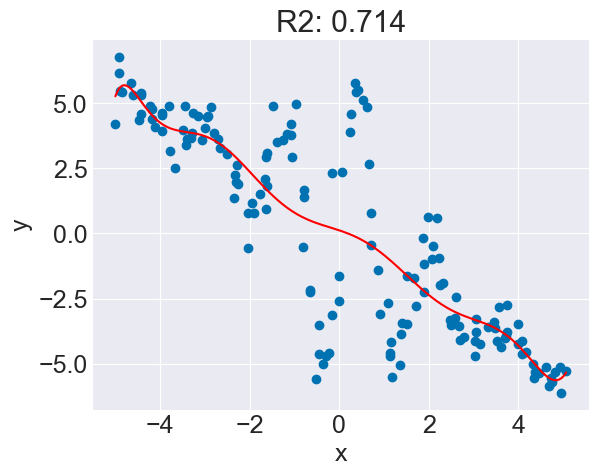

In [107]:
# YOUR CODE HERE
plt.figure()

poly_lin_reg = linear_regression.LinearRegression(poly_data)

poly_lin_reg.poly_regression('x', 'y', 1)

poly_lin_reg.scatter('x', 'y', 'smh')

print(f'MSE (p=1): {poly_lin_reg.mse}')

plt.figure()

poly_lin_reg.poly_regression('x', 'y', 10)

poly_lin_reg.scatter('x', 'y', 'smh')

print(f'MSE (p=10): {poly_lin_reg.mse}')


### 3d.Polynomial regression with higher degree polynomials

Repeat the steps from the previous subtask, but this time find the smallest polynomial degree that gives you a $R^2 > 0.76$.

Make a plot showing the fitted data with the polynomial that you find.

*Your regression fit should not be a line!*

MSE (p=15): 3.6310832312494488
R2 (p=15): 0.7610786158454532


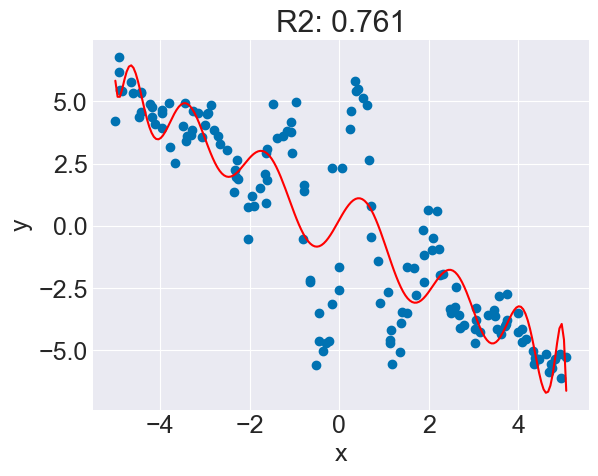

In [108]:
# YOUR CODE HERE
plt.figure()

poly_lin_reg.poly_regression('x', 'y', 15)

poly_lin_reg.scatter('x', 'y', 'smh')

print(f'MSE (p=15): {poly_lin_reg.mse}')
print(f'R2 (p=15): {poly_lin_reg.R2}')


### 3e. Questions

**Question 4:** Is the fit better or worse compared to what you found in Task 3c? Why?

**Answer 4:**

YOUR ANSWER HERE

Better, because we are essentially overfitting the regression line so that it matches our data set

**Question 5:** Describe what happens visually to the shape of the regression curve and in relation to the data as you experiment with the polynomial degree between 1 and the polynomial degree that you found.

**Answer 5:** 

YOUR ANSWER HERE

The lower the degree, the more it was true to the general trend of the data (a downward trend), as our polynomial degree icnreased, the line started shaping more to the literal values of our dataset with curves, becoming more accurate on this specific set but probably worse on actual data.

### 3f. Fit error analysis

Create a plot showing the MSE values as the polynomial degree goes from 1 to the polynomial degree that you found above.

Text(0.5, 1.0, 'MSE vs Poly Degree')

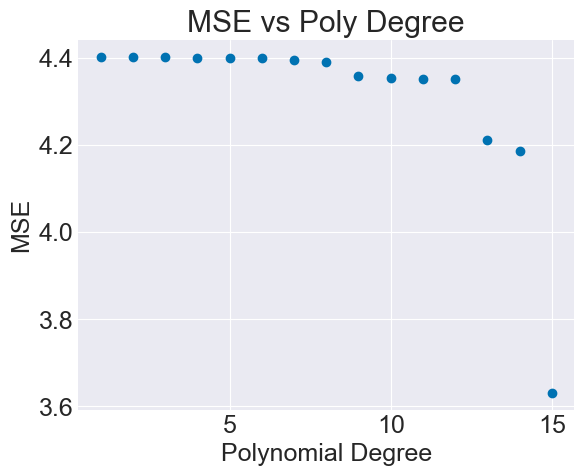

In [109]:
# YOUR CODE HERE

mse_s = []
degrees = []

for i in range(15):
    degrees.append(i+1)
    poly_lin_reg.poly_regression('x', 'y', i + 1)
    degree_mse = poly_lin_reg.mse
    mse_s.append(degree_mse)
    

plt.figure()

plt.scatter(degrees, mse_s)
plt.ylabel("MSE")
plt.xlabel("Polynomial Degree")
plt.title("MSE vs Poly Degree")


### 3g. Questions

**Question 6:** According to the MSE, is the fit generally improving or worsening as $p$ increases?


**Answer 6:**

YOUR ANSWER HERE

It's getting better as we approach a degree of 15 as MSE is dropping

## Task 4: Overfitting

In this subtask, you will experiment with how polynomial regression generalize to data not used to fit the regression model.

### 4a. Create fit and validation sets

The `wave.csv` dataset has 300 samples ($N=300$). In the cell below, split these samples into two separate "datasets" and create 2 `Data` objects representing:
- The first 50% of samples will be used to fit the regression model (i.e. run linear regression on these samples). We will call this the **fit set** (data used to fit the regression).
- The second 50% of samples will be set aside and only used to check how well the fitted regression generalizes to new data. We will call this the **validation set**.

The data samples are already shuffled.

*Hint: There is a helpful `Data` method for paring down a dataset into a certain range of samples.*

In [124]:
# retrieving wave_data (x, y) frmo CSV
data_fit = data.Data("data/wave.csv")
data_val = data.Data("data/wave.csv")

n = 300

data_fit.limit_samples(0,n//2)
data_val.limit_samples(n//2,n)


#### Test: Fit and validation sets

In [126]:
# NOTE: The Data object containing the fit dataset in the test below is called `data_fit`
# The The Data object containing the validation dataset in the test below is called `data_val`
print(f'The first sample of the fit data is\n{data_fit.get_sample(0)} and it should be')
print('[-4.5635  5.0392]')
print(f'The last sample of the fit data is\n{data_fit.get_sample(149)} and it should be')
print('[ 1.2476 -3.9375]')
print(f'The first sample of the val data is\n{data_val.get_sample(0)} and it should be')
print('[-0.7677 -2.8413]')
print(f'The last sample of the val data is\n{data_val.get_sample(149)} and it should be')
print('[ 4.1889 -3.9513]')

The first sample of the fit data is
[-4.5635  5.0392] and it should be
[-4.5635  5.0392]
The last sample of the fit data is
[ 1.2476 -3.9375] and it should be
[ 1.2476 -3.9375]
The first sample of the val data is
[-0.7677 -2.8413] and it should be
[-0.7677 -2.8413]
The last sample of the val data is
[ 4.1889 -3.9513] and it should be
[ 4.1889 -3.9513]


### 4b. Copying fitted regression coefficients

Because we fit the polynomial regression on the fit set, the fitted coefficients are stored in the fit set, `LinearRegression` object. To visualize the predictions on the validation set, we will need to first copy over the coefficients from the fit set `LinearRegression` object to the validation set `LinearRegression` object.

Implement the following methods to accomplish this:
- `get_fitted_slope`: return the fitted regression slopes.
- `get_fitted_intercept`: return the fitted regression intercept.
- `initialize(ind_vars, dep_var, slope, intercept, p)`: set fields based on passed in parameter values.

### 4c. Check fit generalization on validation set

In the cell below, fit a degree 20 polynomial regression model to the fit set and assess generalization on the validation set.

Checklist for what to include:
1. Fit a polynomial regression model with polynomial degree 20 on the fit set.
2. Create 2 scatter plots:
    - Showing the fit set and regression curve fitted to it.
    - Showing the validation set and regression curve that uses the fitted coefficients to the **fit set**.
3. Compute and print the MSE for both the fit and validation sets.

Fit MSE: 2.214014207228187
Validation MSE: 5.649521658855471


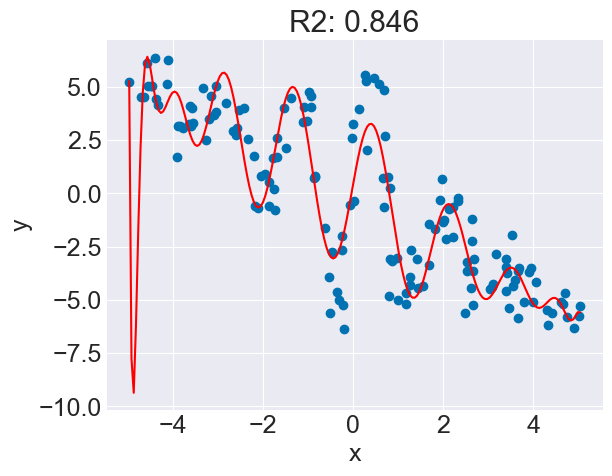

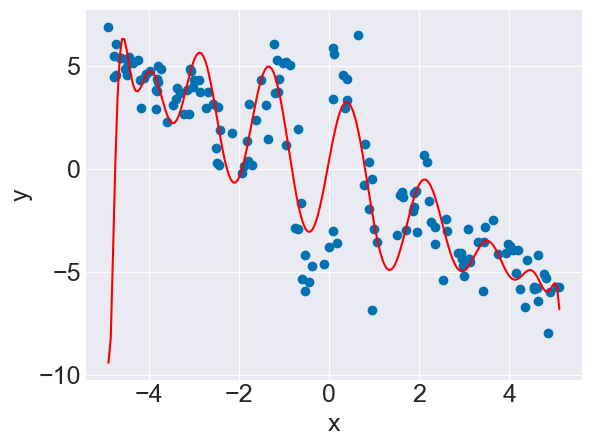

In [ ]:
# YOUR CODE HERE
lin_reg_fit = linear_regression.LinearRegression(data_fit)
lin_reg_fit.poly_regression('x', 'y', 20)
lin_reg_fit.scatter('x', 'y', "smh")

plt.figure()

lin_reg_val = linear_regression.LinearRegression(data_val)
lin_reg_val.initialize(lin_reg_fit.ind_vars, lin_reg_fit.dep_var, lin_reg_fit.slope, lin_reg_fit.intercept, lin_reg_fit.p)

lin_reg_val.scatter('x', 'y', "")

print('Fit MSE:', lin_reg_fit.compute_mse())
x_val = lin_reg_val.data.select_data(lin_reg_val.ind_vars, rows=[])
y_val = lin_reg_val.data.select_data([lin_reg_val.dep_var], rows=[])
y_pred_val = lin_reg_val.predict(X=x_val)
mse_val = float(np.sum((y_val - y_pred_val)**2) / len(y_val))
print('Validation MSE:', mse_val)

### 4d. Questions

**Question 7:** How do the fitted coefficients obtained for the fit set generalize to the validation set. Why?

**Answer 7:** 

YOUR ANSWER HERE

The MSE for the validation set is more than double than that of the fit set. So it did horrible on a new set of data. It's because we fit with such a high degree polynomial that we fitted too much to the trends in the data itself.

### 4e. Acceptable generalization

Find a polynomial degree that you believe yields acceptable generalization to the validation set. Make a plot and report several metrics that justify your finding.

**Note:** Base your decision making upon the metrics, even though you might think the visual appearance is not "ideal".

In [153]:
# YOUR CODE HERE

best_score = float('inf')
best_degree = 0

for i in range(20):
    lin_reg_fit = linear_regression.LinearRegression(data_fit)
    lin_reg_fit.poly_regression('x', 'y', i + 1)
    # lin_reg_fit.scatter('x', 'y', "smh")

    # plt.figure()

    lin_reg_val = linear_regression.LinearRegression(data_val)
    lin_reg_val.initialize(lin_reg_fit.ind_vars, lin_reg_fit.dep_var, lin_reg_fit.slope, lin_reg_fit.intercept, lin_reg_fit.p)

    # lin_reg_val.scatter('x', 'y', "")

    # computing the mse_val on the unfitted validation set
    x_val = lin_reg_val.data.select_data(lin_reg_val.ind_vars, rows=[])
    y_val = lin_reg_val.data.select_data([lin_reg_val.dep_var], rows=[])
    y_pred_val = lin_reg_val.predict(X=x_val)
    mse_val = float(np.sum((y_val - y_pred_val)**2) / len(y_val))
    best_score = min(best_score, mse_val)
    if best_score == mse_val:
        best_degree = i + 1

print(f"At degree {best_degree}, the best mse is {best_score}")

At degree 9, the best mse is 5.0706860521966455


MSE value of fit set: 5.038406910107916
MSE value of validation set: 5.0706860521966455


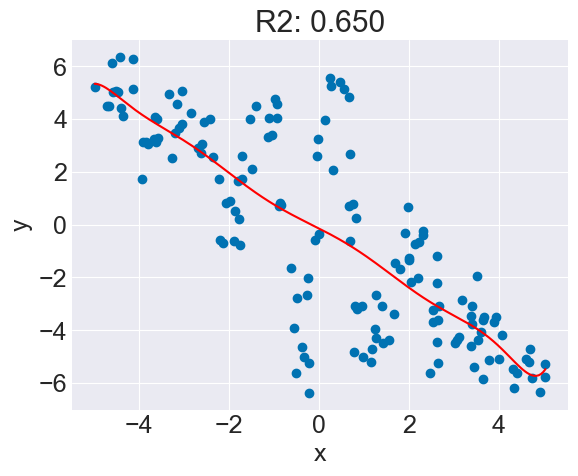

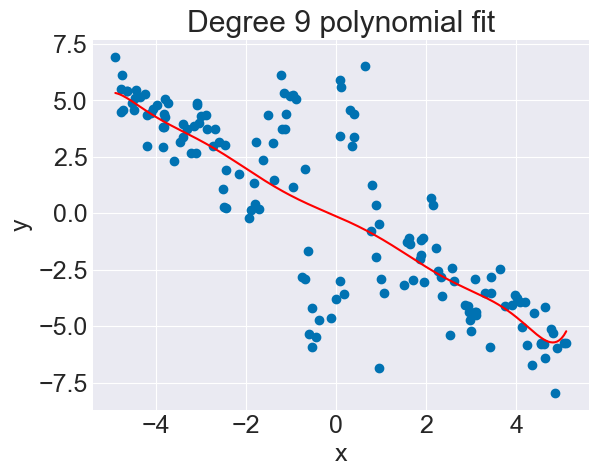

In [161]:
# YOUR CODE HERE

# plotting the degree 9
lin_reg_fit = linear_regression.LinearRegression(data_fit)
lin_reg_fit.poly_regression('x', 'y', 9)
lin_reg_fit.scatter('x', 'y', "smh")

plt.figure()

lin_reg_val = linear_regression.LinearRegression(data_val)
lin_reg_val.initialize(lin_reg_fit.ind_vars, lin_reg_fit.dep_var, lin_reg_fit.slope, lin_reg_fit.intercept, lin_reg_fit.p)

lin_reg_val.scatter('x', 'y', "Degree 9 polynomial fit")

# computing the mse_val on the unfitted validation set
x_val = lin_reg_val.data.select_data(lin_reg_val.ind_vars, rows=[])
y_val = lin_reg_val.data.select_data([lin_reg_val.dep_var], rows=[])
y_pred_val = lin_reg_val.predict(X=x_val)
mse_val = float(np.sum((y_val - y_pred_val)**2) / len(y_val))

print(f"MSE value of fit set: {lin_reg_fit.mse}")
print(f"MSE value of validation set: {mse_val}")

# I also just calculated the MSE for degrees 1-20 and got the minimum; that should be evidence enough

In [162]:
lin_reg_fit = linear_regression.LinearRegression(data_fit)
lin_reg_fit.poly_regression('x', 'y', 8)
# lin_reg_fit.scatter('x', 'y', "smh")

# plt.figure()

lin_reg_val = linear_regression.LinearRegression(data_val)
lin_reg_val.initialize(lin_reg_fit.ind_vars, lin_reg_fit.dep_var, lin_reg_fit.slope, lin_reg_fit.intercept, lin_reg_fit.p)

# lin_reg_val.scatter('x', 'y', "Degree 9 polynomial fit")

# computing the mse_val on the unfitted validation set
x_val = lin_reg_val.data.select_data(lin_reg_val.ind_vars, rows=[])
y_val = lin_reg_val.data.select_data([lin_reg_val.dep_var], rows=[])
y_pred_val = lin_reg_val.predict(X=x_val)
mse_val = float(np.sum((y_val - y_pred_val)**2) / len(y_val))

print("Degree 8:")
print(f"MSE value of fit set: {lin_reg_fit.mse}")
print(f"MSE value of validation set: {mse_val}")

lin_reg_fit = linear_regression.LinearRegression(data_fit)
lin_reg_fit.poly_regression('x', 'y', 10)
# lin_reg_fit.scatter('x', 'y', "smh")

# plt.figure()

lin_reg_val = linear_regression.LinearRegression(data_val)
lin_reg_val.initialize(lin_reg_fit.ind_vars, lin_reg_fit.dep_var, lin_reg_fit.slope, lin_reg_fit.intercept, lin_reg_fit.p)

# lin_reg_val.scatter('x', 'y', "Degree 9 polynomial fit")

# computing the mse_val on the unfitted validation set
x_val = lin_reg_val.data.select_data(lin_reg_val.ind_vars, rows=[])
y_val = lin_reg_val.data.select_data([lin_reg_val.dep_var], rows=[])
y_pred_val = lin_reg_val.predict(X=x_val)
mse_val = float(np.sum((y_val - y_pred_val)**2) / len(y_val))

print("Degree 10:")
print(f"MSE value of fit set: {lin_reg_fit.mse}")
print(f"MSE value of validation set: {mse_val}")

Degree 8:
MSE value of fit set: 5.043578533304649
MSE value of validation set: 5.082059997804322
Degree 10:
MSE value of fit set: 5.0192170231279745
MSE value of validation set: 5.159282107156711
